# Questão 2

A compressão agora é feita com a DFT/FFT sobre o mesmo áudio [../data/handel.wav](../data/handel.wav),
mantendo os mesmos percentuais de energia da questão anterior para permitir comparação direta com a DCT.


In [1]:
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
from IPython.display import Audio, display
from scipy.io import wavfile
from scipy.fft import dct, idct, fft, ifft, dctn, idctn
from PIL import Image

plt.style.use('seaborn-v0_8-whitegrid')

CWD = Path.cwd().resolve()
if (CWD / 'sosias.jpg').exists():
    PRACTICE_DIR = CWD
elif (CWD / 'pratica_4' / 'sosias.jpg').exists():
    PRACTICE_DIR = (CWD / 'pratica_4').resolve()
else:
    PRACTICE_DIR = CWD

DATA_DIR = (PRACTICE_DIR.parent / 'data').resolve()
AUDIO_PATH = DATA_DIR / 'handel.wav'
IMAGE_PATH = (PRACTICE_DIR / 'sosias.jpg').resolve()


In [2]:
def to_float_mono(signal):
    signal = np.asarray(signal)
    if signal.ndim > 1:
        signal = signal.mean(axis=1)

    signal = signal.astype(np.float64)
    peak = np.max(np.abs(signal))
    if peak > 0:
        signal = signal / peak
    return signal


def show_audio(signal, fs, label):
    signal = np.asarray(signal, dtype=np.float64)
    peak = np.max(np.abs(signal))
    if peak > 0:
        signal = signal / peak
    display(Audio(signal, rate=fs))
    print(label)


def mse(reference, estimate):
    reference = np.asarray(reference, dtype=np.float64)
    estimate = np.asarray(estimate, dtype=np.float64)
    return float(np.mean((reference - estimate) ** 2))


def display_rows(rows, float_digits=6):
    if not rows:
        print('Sem dados para exibir.')
        return

    headers = list(rows[0].keys())
    formatted_rows = []
    for row in rows:
        formatted = []
        for header in headers:
            value = row[header]
            if isinstance(value, float):
                formatted.append(f'{value:.{float_digits}f}')
            else:
                formatted.append(str(value))
        formatted_rows.append(formatted)

    widths = []
    for idx, header in enumerate(headers):
        content_width = max(len(row[idx]) for row in formatted_rows)
        widths.append(max(len(header), content_width))

    header_line = ' | '.join(header.ljust(widths[idx]) for idx, header in enumerate(headers))
    separator = '-+-'.join('-' * width for width in widths)
    print(header_line)
    print(separator)
    for row in formatted_rows:
        print(' | '.join(value.ljust(widths[idx]) for idx, value in enumerate(row)))


def select_by_energy(coeffs, keep_energy):
    coeffs = np.asarray(coeffs)
    energy = np.abs(coeffs) ** 2
    flat_energy = energy.ravel()
    order = np.argsort(flat_energy)[::-1]
    cumulative = np.cumsum(flat_energy[order])
    total_energy = cumulative[-1]
    threshold = keep_energy * total_energy
    keep_count = int(np.searchsorted(cumulative, threshold, side='left')) + 1

    mask = np.zeros(coeffs.size, dtype=bool)
    mask[order[:keep_count]] = True
    mask = mask.reshape(coeffs.shape)

    compressed = np.zeros_like(coeffs)
    compressed[mask] = coeffs[mask]
    retained = float(np.sum(np.abs(compressed) ** 2) / total_energy)
    return compressed, keep_count, retained, mask


def compress_audio_dct(signal, keep_energy):
    coeffs = dct(signal, norm='ortho')
    compressed, keep_count, retained, _ = select_by_energy(coeffs, keep_energy)
    reconstructed = idct(compressed, norm='ortho')
    return {
        'coeffs': coeffs,
        'compressed_coeffs': compressed,
        'reconstructed': reconstructed,
        'keep_count': keep_count,
        'retained_energy': retained,
    }


def compress_audio_fft(signal, keep_energy):
    coeffs = fft(signal)
    compressed, keep_count, retained, _ = select_by_energy(coeffs, keep_energy)
    reconstructed = np.real(ifft(compressed))
    return {
        'coeffs': coeffs,
        'compressed_coeffs': compressed,
        'reconstructed': reconstructed,
        'keep_count': keep_count,
        'retained_energy': retained,
    }


def plot_time_and_error(original, reconstructed, fs, title):
    t = np.arange(len(original)) / fs
    fig, axes = plt.subplots(2, 1, figsize=(12, 6), sharex=True)
    axes[0].plot(t, original, label='Original', alpha=0.8)
    axes[0].plot(t, reconstructed, label='Reconstruido', alpha=0.7)
    axes[0].set_title(title)
    axes[0].set_ylabel('Amplitude')
    axes[0].legend()

    axes[1].plot(t, original - reconstructed, color='tab:red')
    axes[1].set_title('Erro de reconstrução')
    axes[1].set_xlabel('Tempo (s)')
    axes[1].set_ylabel('Erro')
    plt.tight_layout()
    plt.show()


In [3]:
fs, raw_signal = wavfile.read(AUDIO_PATH)
signal = to_float_mono(raw_signal)
show_audio(signal, fs, 'Audio original: handel.wav')


Audio original: handel.wav


In [4]:
keep_levels = [0.995, 0.99, 0.90, 0.75, 0.50]
results = {}
rows = []

for keep in keep_levels:
    result = compress_audio_fft(signal, keep)
    reconstructed = result['reconstructed']
    key = f'{keep * 100:.1f}%'
    results[key] = result
    rows.append(
        {
            'Energia preservada': key,
            'Coeficientes mantidos': result['keep_count'],
            'Percentual de coeficientes': 100 * result['keep_count'] / len(signal),
            'Energia efetiva (%)': 100 * result['retained_energy'],
            'MSE': mse(signal, reconstructed),
        }
    )

display_rows(rows, float_digits=8)


Energia preservada | Coeficientes mantidos | Percentual de coeficientes | Energia efetiva (%) | MSE       
-------------------+-----------------------+----------------------------+---------------------+-----------
99.5%              | 48670                 | 66.56818897                | 99.50001286         | 0.00030079
99.0%              | 40986                 | 56.05843010                | 99.00007993         | 0.00060155
90.0%              | 11661                 | 15.94928399                | 90.00012777         | 0.00601615
75.0%              | 4325                  | 5.91550066                 | 75.00188443         | 0.01503943
50.0%              | 1170                  | 1.60026261                 | 50.01082223         | 0.03007461


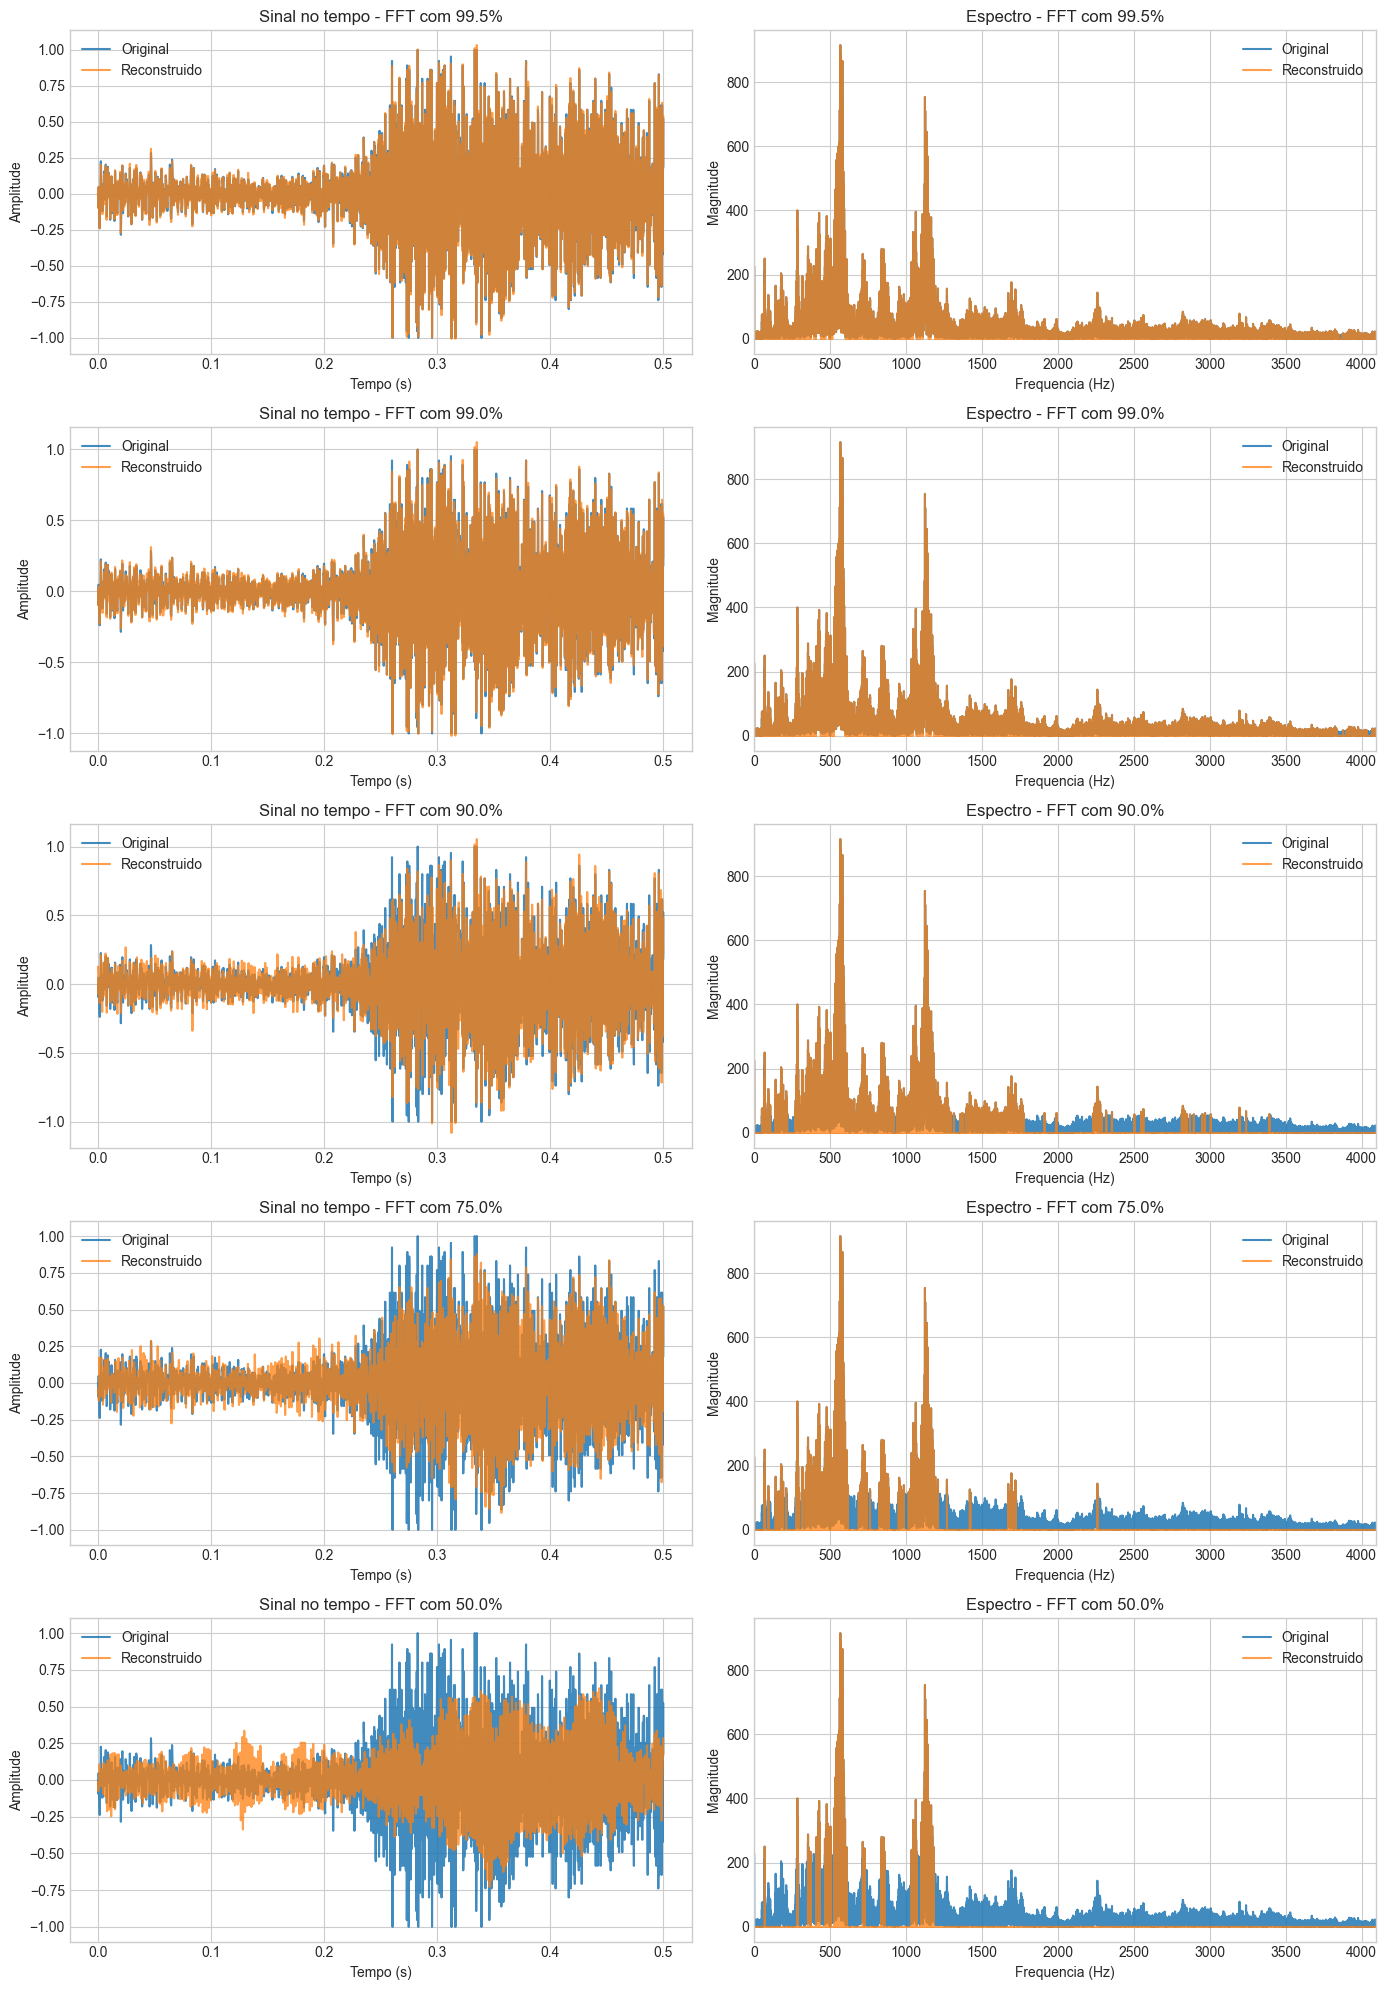

In [5]:
fig, axes = plt.subplots(len(results), 2, figsize=(14, 4 * len(results)))
time = np.arange(len(signal)) / fs
snippet = slice(0, min(len(signal), fs // 2))
freq = np.fft.rfftfreq(len(signal), d=1 / fs)
spectrum_original = np.abs(np.fft.rfft(signal))

for idx, (label, result) in enumerate(results.items()):
    reconstructed = result['reconstructed']

    axes[idx, 0].plot(time[snippet], signal[snippet], label='Original', alpha=0.85)
    axes[idx, 0].plot(time[snippet], reconstructed[snippet], label='Reconstruido', alpha=0.75)
    axes[idx, 0].set_title(f'Sinal no tempo - FFT com {label}')
    axes[idx, 0].set_xlabel('Tempo (s)')
    axes[idx, 0].set_ylabel('Amplitude')
    axes[idx, 0].legend()

    spectrum_reconstructed = np.abs(np.fft.rfft(reconstructed))
    axes[idx, 1].plot(freq, spectrum_original, label='Original', alpha=0.85)
    axes[idx, 1].plot(freq, spectrum_reconstructed, label='Reconstruido', alpha=0.75)
    axes[idx, 1].set_title(f'Espectro - FFT com {label}')
    axes[idx, 1].set_xlabel('Frequencia (Hz)')
    axes[idx, 1].set_ylabel('Magnitude')
    axes[idx, 1].set_xlim(0, fs / 2)
    axes[idx, 1].legend()

plt.tight_layout()
plt.show()


In [6]:
for label, result in results.items():
    show_audio(result['reconstructed'], fs, f'Audio reconstruido com FFT preservando {label} de energia')


Audio reconstruido com FFT preservando 99.5% de energia


Audio reconstruido com FFT preservando 99.0% de energia


Audio reconstruido com FFT preservando 90.0% de energia


Audio reconstruido com FFT preservando 75.0% de energia


Audio reconstruido com FFT preservando 50.0% de energia


## Comentários

- A FFT também permite compressão, mas tende a exigir mais coeficientes para manter a mesma qualidade perceptual.
- Como a DFT representa o sinal com senos e cossenos complexos, a compactação de energia é menos eficiente do que na DCT.
- Por isso, para a mesma meta de energia, a reconstrução pela FFT costuma apresentar MSE maior ou menor taxa de compressão efetiva.
